# Time-Resolved NAF — Photon Breakdown (count-space, full-angle noisy)

Parallel setting to the limited-angle study: **each frame is full 0-180 deg but
photon-starved**. The Poisson process lives in the raw counts, so the model is
fit in **count space** — predict `lambda_hat = flat*exp(-p_hat)` and score against
counts `N` via Poisson NLL (never comparing to `-ln(N/I0)`). Same NAF model as the
limited-angle work; only the data representation, loss, and baseline differ.

This notebook loads the runs produced by
`scripts/tr_naf_sweep.py --regime noise --photons ...` (dirs
`checkpoints/tr_naf/noise/212_I0-*`) and plots how reconstruction quality degrades
as the photon budget `I0` drops — and where it falls to the per-frame FBP baseline.

In [1]:
import sys, json
from pathlib import Path
import numpy as np, torch, matplotlib.pyplot as plt
sys.path.insert(0,'/myhome/sdate'); sys.path.insert(0,'/myhome/astra-torch'); sys.path.insert(0,'/myhome/chip-project')
from sdate.tr_naf import load_result, reconstruct_volume_at, evaluate_frames, make_circular_mask
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NOISE_ROOT = Path('/myhome/sdate/checkpoints/tr_naf/noise')
# Which photon-sweep to view: '212mid_I0-*' = fast-dynamics window (04345-04394);
# '212_I0-*' = the earlier slow (near-static) window.
RUN_GLOB = '212mid_I0-*'
plt.rcParams['image.cmap']='gray'
print('device:', device, '| runs:', NOISE_ROOT/RUN_GLOB)

device: cuda | runs: /myhome/sdate/checkpoints/tr_naf/noise/212mid_I0-*


## 1. Load every photon level

In [2]:
def scale_matched_psnr(pred, gt, mask, data_range):
    # FBP has arbitrary intensity scale; fit a single scalar alpha before PSNR for a fair baseline.
    p = pred[:, mask].reshape(-1); g = gt[:, mask].reshape(-1)
    alpha = float((p*g).sum() / (p*p).sum().clamp_min(1e-8))
    mse = ((alpha*pred - gt)[:, mask]**2).mean()
    return float(10*torch.log10(torch.tensor(data_range**2)/mse.clamp_min(1e-12)))

runs = []   # one dict per I0
for d in sorted(NOISE_ROOT.glob(RUN_GLOB)):
    if not (d/'acquisition.pt').exists() or not list(d.glob('K*.pt')): continue
    acq = torch.load(d/'acquisition.pt', map_location=device, weights_only=False)
    meta = acq['meta']; I0 = float(meta['photons']); scale = float(acq.get('scale',1.0))
    gt = [v.to(device) for v in acq['true_volumes']]; times = acq['times']
    C = gt[0].shape[-1]; mask = make_circular_mask(C,C,device=device)
    dr = acq['data_range']
    fbp = [acq['sw_fbp'][i].to(device) for i in range(acq['sw_fbp'].shape[0])]  # per-frame FBP
    Kp = sorted(d.glob('K*.pt'))[0]; K = int(Kp.stem[1:])
    res,_ = load_result(Kp, device=device)
    naf = [reconstruct_volume_at(res,t)/scale for t in times]
    m_naf = evaluate_frames(naf, gt, mask=mask, data_range=dr)
    m_fbp = evaluate_frames(fbp, gt, mask=mask, data_range=dr)
    fbp_sm = float(np.mean([scale_matched_psnr(fbp[i], gt[i], mask, dr) for i in range(len(gt))]))
    runs.append(dict(I0=I0, K=K, scale=scale, meta=meta, gt=gt, times=times, mask=mask, dr=dr,
                     naf=naf, fbp=fbp, m_naf=m_naf, m_fbp=m_fbp, fbp_psnr_sm=fbp_sm))
    print(f"I0={I0:.0e} K={K}: NAF {m_naf['psnr'].mean():5.2f}dB/{m_naf['ssim'].mean():.3f} | "
          f"FBP {m_fbp['psnr'].mean():5.2f}dB (scale-matched {fbp_sm:5.2f}) /{m_fbp['ssim'].mean():.3f}")
runs.sort(key=lambda r: r['I0'])
I0s = [r['I0'] for r in runs]
print('\nphoton levels:', [f'{x:.0e}' for x in I0s])

I0=1e+02 K=12: NAF 22.92dB/0.456 | FBP 12.74dB (scale-matched 12.96) /0.111


I0=1e+03 K=12: NAF 25.73dB/0.674 | FBP 16.47dB (scale-matched 21.47) /0.389


I0=1e+04 K=12: NAF 25.46dB/0.671 | FBP 17.03dB (scale-matched 25.79) /0.650


I0=1e+05 K=12: NAF 25.88dB/0.710 | FBP 17.09dB (scale-matched 26.60) /0.717


I0=3e+02 K=12: NAF 24.25dB/0.546 | FBP 15.25dB (scale-matched 17.30) /0.224

photon levels: ['1e+02', '3e+02', '1e+03', '1e+04', '1e+05']


## 2. Breakdown table + curves (quality vs photon budget)

In [3]:
import pandas as pd
rows=[]
for r in runs:
    rows.append({'I0': f"{r['I0']:.0e}",
                 'NAF PSNR': r['m_naf']['psnr'].mean(), 'NAF SSIM': r['m_naf']['ssim'].mean(),
                 'FBP PSNR (sm)': r['fbp_psnr_sm'], 'FBP SSIM': r['m_fbp']['ssim'].mean()})
df = pd.DataFrame(rows).set_index('I0').round(3); df

,NAF PSNR,NAF SSIM,FBP PSNR (sm),FBP SSIM
I0,,,,
1e+02,22.919,0.456,12.965,0.111
3e+02,24.254,0.546,17.298,0.224
1e+03,25.726,0.674,21.471,0.389
1e+04,25.458,0.671,25.787,0.650
1e+05,25.881,0.710,26.597,0.717


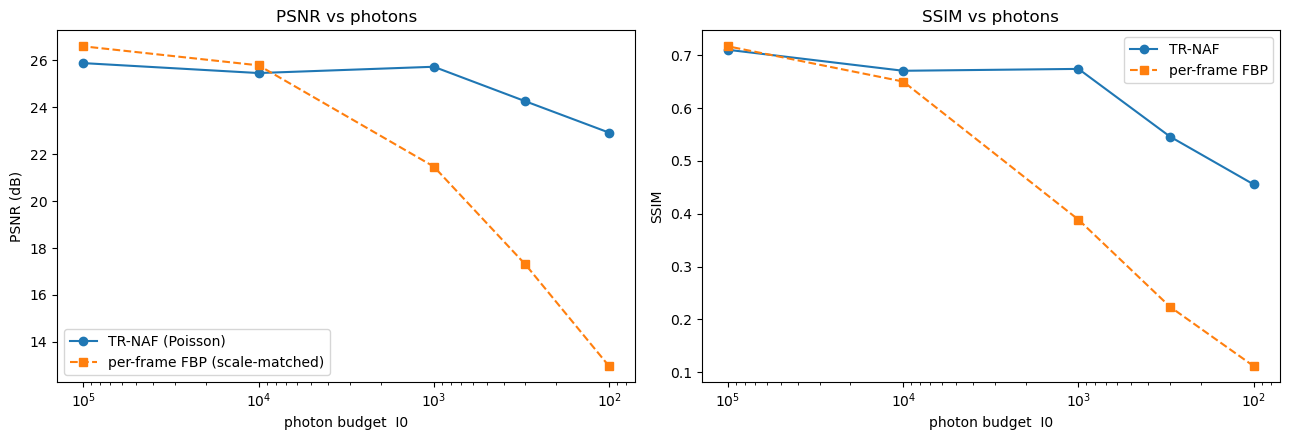

x-axis inverted: left = clean (high I0), right = photon-starved (low I0)


In [4]:
fig, ax = plt.subplots(1,2, figsize=(13,4.5))
ax[0].semilogx(I0s, [r['m_naf']['psnr'].mean() for r in runs], 'o-', label='TR-NAF (Poisson)')
ax[0].semilogx(I0s, [r['fbp_psnr_sm'] for r in runs], 's--', label='per-frame FBP (scale-matched)')
ax[0].set_xlabel('photon budget  I0'); ax[0].set_ylabel('PSNR (dB)'); ax[0].legend(); ax[0].set_title('PSNR vs photons'); ax[0].invert_xaxis()
ax[1].semilogx(I0s, [r['m_naf']['ssim'].mean() for r in runs], 'o-', label='TR-NAF')
ax[1].semilogx(I0s, [r['m_fbp']['ssim'].mean() for r in runs], 's--', label='per-frame FBP')
ax[1].set_xlabel('photon budget  I0'); ax[1].set_ylabel('SSIM'); ax[1].legend(); ax[1].set_title('SSIM vs photons'); ax[1].invert_xaxis()
plt.tight_layout(); plt.show()
print('x-axis inverted: left = clean (high I0), right = photon-starved (low I0)')

## 3. Where it breaks — mid-slice across the photon sweep
Rows: GT / per-frame FBP / TR-NAF.  Columns: clean → starved.

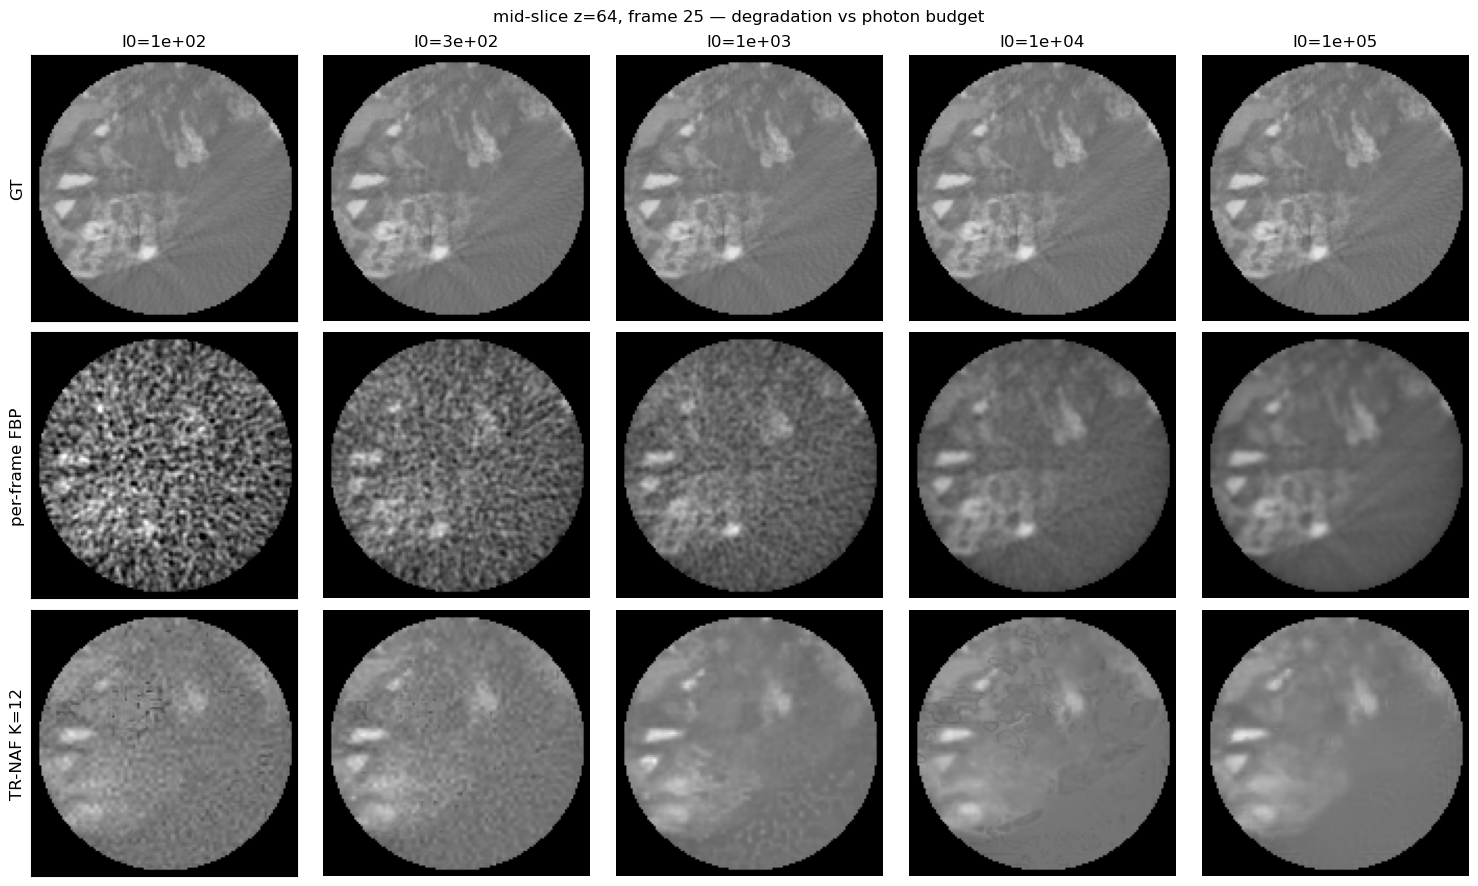

In [5]:
fi = len(runs[0]['times'])//2   # middle time frame
z = runs[0]['gt'][0].shape[0]//2
gt0 = runs[0]['gt']; mask = runs[0]['mask']
vmax = float(torch.stack(gt0)[:, :, mask].max())
n = len(runs)
fig, axes = plt.subplots(3, n, figsize=(3*n, 9))
for c, r in enumerate(runs):
    imgs = [r['gt'][fi][z], r['fbp'][fi][z], r['naf'][fi][z]]
    for row, im in enumerate(imgs):
        axes[row, c].imshow((im*mask).cpu(), vmin=0, vmax=vmax); axes[row, c].axis('off')
    axes[0, c].set_title(f"I0={r['I0']:.0e}")
for row, lab in enumerate(['GT','per-frame FBP',f"TR-NAF K={runs[0]['K']}"]):
    axes[row,0].axis('on'); axes[row,0].set_xticks([]); axes[row,0].set_yticks([]); axes[row,0].set_ylabel(lab, size=12)
plt.suptitle(f'mid-slice z={z}, frame {fi} — degradation vs photon budget'); plt.tight_layout(); plt.show()

## Notes
- **Count-space fit.** Loss is Poisson NLL on `lambda_hat = flat*exp(-p_hat)` vs raw counts; the field warm-starts at mu~0 (p_hat~0, lambda~I0) for stable early gradients.
- **Baseline.** Per-frame full-angle FBP log-corrects the counts (`-ln((N-dark)/I0)`) then filters. Its absolute PSNR is scale-dependent, so we report a **scale-matched** PSNR (fit one scalar) for fairness; SSIM needs no such correction.
- **Reading the curves.** Left = clean (upper bound; large-K NAF should fit near-perfectly). Moving right, watch where TR-NAF's advantage over FBP narrows — that's the photon-starved breakpoint.
- Same runs reproducible via `scripts/tr_naf_sweep.py --regime noise --photons <I0>`. Add `--read-noise` + `--data-fidelity anscombe` for the Poisson-Gaussian floor.